In [4]:
import pandas as pd

In [5]:
#open the file and explore the data
teams = pd.read_csv("teams.csv")
teams.head()

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [6]:
teams.describe()

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
count,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2014.000000,2014.000000
mean,1994.507463,35.724813,73.693097,24.778591,173.900233,69.271595,10.556437,10.248759,9.449901
std,15.384205,49.490270,127.907577,2.808559,5.357367,7.606507,33.028143,31.951920,28.232227
min,1964.000000,1.000000,1.000000,17.000000,151.000000,43.000000,0.000000,0.000000,0.000000
25%,1984.000000,6.000000,7.000000,23.275000,170.500000,64.500000,0.000000,0.000000,0.000000
50%,1996.000000,13.000000,19.000000,24.700000,174.400000,69.400000,0.000000,0.000000,0.300000
75%,2008.000000,44.000000,70.250000,26.100000,177.300000,73.400000,4.000000,4.000000,4.650000
max,2016.000000,270.000000,839.000000,66.000000,193.000000,148.000000,442.000000,442.000000,314.000000


In [ ]:
#keep only the columns relevant to medal prediction
teams = teams[["team", "country", "year", "athletes","medals", "prev_medals"]]
teams

,team,country,year,athletes,medals,prev_medals
0,AFG,Afghanistan,1964,8,0,0.0
1,AFG,Afghanistan,1968,5,0,0.0
2,AFG,Afghanistan,1972,8,0,0.0
3,AFG,Afghanistan,1980,11,0,0.0
4,AFG,Afghanistan,2004,5,0,0.0
...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,0,0.0
2140,ZIM,Zimbabwe,2004,14,3,0.0
2141,ZIM,Zimbabwe,2008,16,4,3.0
2142,ZIM,Zimbabwe,2012,9,0,4.0


In [ ]:
#check how strong these columns are correlated with medal count
#This gives how useful variables are for prediction

teams.corr(numeric_only = True)["medals"]
#or teams.select_dtypes(include=['number'].corr()["medals"])


year          -0.021603
athletes       0.840817
medals         1.000000
prev_medals    0.920048
Name: medals, dtype: float64

In [ ]:
#Visualize the linear relationship between the number of athletes and the number of medals won

import seaborn as sb

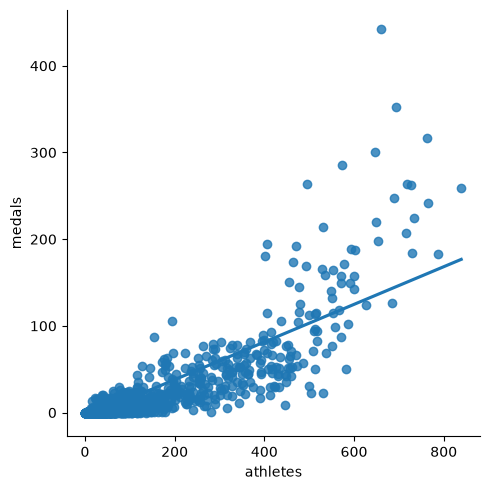

In [11]:
sb.lmplot(x="athletes", y="medals", data=teams, fit_reg=True, ci=None)

<Axes: ylabel='Frequency'>

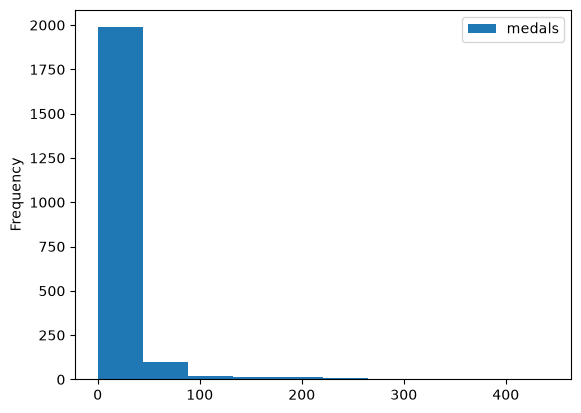

In [ ]:
#It plots the distribution of medal counts
teams.plot.hist(y="medals" )

In [ ]:
#check for any null values
teams.isnull().sum()

team             0
country          0
year             0
athletes         0
medals           0
prev_medals    130
dtype: int64

In [ ]:

teams[teams.isnull().any(axis=1)]

,team,country,year,athletes,medals,prev_medals
19,ALB,Albania,1992,9,0,NaN
26,ALG,Algeria,1964,7,0,NaN
39,AND,Andorra,1976,3,0,NaN
50,ANG,Angola,1980,17,0,NaN
59,ANT,Antigua and Barbuda,1976,17,0,NaN
...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,0,NaN
2103,YAR,North Yemen,1984,3,0,NaN
2105,YEM,Yemen,1992,8,0,NaN
2112,YMD,South Yemen,1988,5,0,NaN


In [ ]:
#drop all rows that has null values
teams = teams.dropna()
teams

,team,country,year,athletes,medals,prev_medals
0,AFG,Afghanistan,1964,8,0,0.0
1,AFG,Afghanistan,1968,5,0,0.0
2,AFG,Afghanistan,1972,8,0,0.0
3,AFG,Afghanistan,1980,11,0,0.0
4,AFG,Afghanistan,2004,5,0,0.0
...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,0,0.0
2140,ZIM,Zimbabwe,2004,14,3,0.0
2141,ZIM,Zimbabwe,2008,16,4,3.0
2142,ZIM,Zimbabwe,2012,9,0,4.0


In [ ]:
# split the data into training set uses data before 2012, and testing set from 2012 and later.
# It uses the past Olympic results to predict future results

train = teams[teams["year"]<2012].copy()
test = teams[teams["year"]>=2012].copy()

In [17]:
train.shape


(1609, 6)

In [18]:
test.shape

(405, 6)

In [ ]:
#import built-in Linear Regression model to train and predict 

from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [ ]:
# select the features used to predict medal count
#athletes represent the size of the country's team
#prev_medals provide info about the country's prev medals
#Using two type of the best correlated data to train using only historical data
predictors = ["athletes", "prev_medals"]
reg.fit(train[predictors], train["medals"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.07,0.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['athletes','prev_medals']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.142
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [ ]:

predictions = reg.predict(test[predictors])
predictions


array([-9.61221245e-01, -1.17633261e+00, -1.42503158e+00, -1.71184673e+00,
        2.15562926e+00,  3.91463636e+00, -1.71184673e+00, -1.85525431e+00,
        3.67563128e-01, -2.77770967e-01, -1.85525431e+00, -1.49673537e+00,
        4.67519911e+01,  2.87550937e+01,  4.58450091e+00,  2.54773581e+00,
       -1.85525431e+00, -1.64014295e+00, -1.85525431e+00, -1.85525431e+00,
        1.46556876e+02,  1.20571799e+02,  6.56314795e+00,  3.95275254e+00,
        7.34283247e+00,  1.03117468e+01,  5.19171882e+00,  3.58517645e+00,
       -1.64014295e+00, -1.64014295e+00, -1.56843916e+00, -1.20992022e+00,
       -1.71184673e+00, -1.42503158e+00,  1.17929959e+01,  1.00049298e+01,
       -1.78355052e+00, -1.71184673e+00, -1.56843916e+00, -1.56843916e+00,
       -1.99866189e+00, -1.99866189e+00, -1.56843916e+00, -1.35332779e+00,
       -1.92695810e+00, -1.92695810e+00,  3.28912706e+01,  2.53042547e+01,
       -1.78355052e+00, -1.28162400e+00, -1.85525431e+00, -3.87590939e-01,
        7.83480779e+01,  

In [ ]:
#compare medal predictions to the test dataframe
test["predictions"]=predictions
test

,team,country,year,athletes,medals,prev_medals,predictions
6,AFG,Afghanistan,2012,6,1,1.0,-0.961221
7,AFG,Afghanistan,2016,3,0,1.0,-1.176333
24,ALB,Albania,2012,10,0,0.0,-1.425032
25,ALB,Albania,2016,6,0,0.0,-1.711847
37,ALG,Algeria,2012,39,1,2.0,2.155629
...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,0,0.0,-1.926958
2131,ZAM,Zambia,2012,7,0,0.0,-1.640143
2132,ZAM,Zambia,2016,7,0,0.0,-1.640143
2142,ZIM,Zimbabwe,2012,9,0,4.0,1.505767


In [ ]:
#round up the negative prediction to be zero and round other positive prediction 
#to integers

test.loc[test["predictions"] < 0, "predictions"] = 0

In [24]:
test["predictions"] = test["predictions"].round()

In [25]:
test

,team,country,year,athletes,medals,prev_medals,predictions
6,AFG,Afghanistan,2012,6,1,1.0,0.0
7,AFG,Afghanistan,2016,3,0,1.0,0.0
24,ALB,Albania,2012,10,0,0.0,0.0
25,ALB,Albania,2016,6,0,0.0,0.0
37,ALG,Algeria,2012,39,1,2.0,2.0
...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,0,0.0,0.0
2131,ZAM,Zambia,2012,7,0,0.0,0.0
2132,ZAM,Zambia,2016,7,0,0.0,0.0
2142,ZIM,Zimbabwe,2012,9,0,4.0,2.0


In [ ]:
#calculate the avarage absolute difference between the predicted value and 
# the actual number of medals won. A lower MAE get the predictions closet to the actual medal counts

from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["medals"], test["predictions"])
error

3.2987654320987656

In [ ]:
#compare the standard deviation of medal count with MAE
teams.describe()["medals"]

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [ ]:
#examine the predictions for two specific teams to see how they perform and the difference between
#actual medals won vs predictions

test[test["team"]=="USA"]

,team,country,year,athletes,medals,prev_medals,predictions
2053,USA,United States,2012,689,248,317.0,285.0
2054,USA,United States,2016,719,264,248.0,236.0


In [29]:
test[test["team"]=="IND"]

,team,country,year,athletes,medals,prev_medals,predictions
907,IND,India,2012,95,6,3.0,7.0
908,IND,India,2016,130,2,6.0,12.0


In [ ]:
#calculate the absolute prediction error and apply the absolute value to get both over-predicitions
# and under-predictions contribute positively to error

errors = (test["medals"] - test["predictions"]).abs()
errors

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [ ]:
#This allows us to see the avarage prediction error for each team
error_by_team = errors.groupby(test["team"]).mean()

In [32]:
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64

In [ ]:
#Calculate the average number of actual medals
medals_by_team = test["medals"].groupby(test["team"]).mean()
#An error ratio gives the differences in the scales of medal counts between countries
error_ratio = error_by_team / medals_by_team
error_ratio

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    inf
Length: 204, dtype: float64

In [ ]:
#Remove teams whose ratio could not be calculated and infinite values

error_ratio[~pd.isnull(error_ratio)] 

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
ZIM         inf
Length: 102, dtype: float64

In [35]:
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]

In [ ]:
#display a cleaned error ratio 
error_ratio

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
UKR    0.951220
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

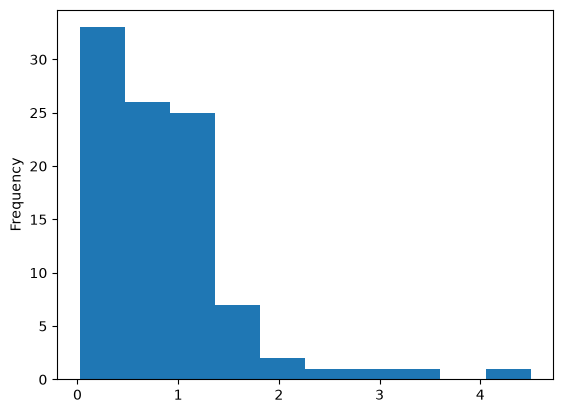

In [ ]:
#plot the distribution to see how prediction error varies across teams
error_ratio.plot.hist()